In [1]:
import Pkg
Pkg.activate(".")
Pkg.status()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising`


Status `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [91a5bcdd] Plots v1.41.6
  [925ea013] ProxTV v1.2.3
  [9a3f8284] Random v1.11.0


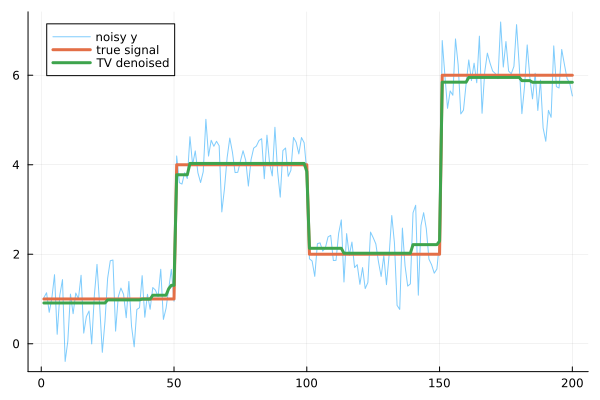

In [12]:
using Random
using Plots

include("src/1D_denoising.jl")

Random.seed!(1)
N = 200
xtrue = vcat(
    fill(1.0, 50),
    fill(4.0, 50),
    fill(2.0, 50),
    fill(6.0, 50)
)
y = xtrue .+ 0.5 .* randn(N)
λ = 3.0
xdenoised = tv1d_condat(y, λ)
plot(y, label="noisy y", alpha=0.5)
plot!(xtrue, label="true signal", linewidth=3)
plot!(xdenoised, label="TV denoised", linewidth=3)

In [13]:
using BenchmarkTools
using ProxTV
using Random

Random.seed!(1)
N = 200
xtrue = vcat(
    fill(1.0, 50),
    fill(4.0, 50),
    fill(2.0, 50),
    fill(6.0, 50)
)
y = xtrue .+ 0.5 .* randn(N)
λ = 3.0
x1 = tv1d_condat(y, λ)

h = NormTVp(λ, 1.0, N)
x2 = similar(y)
prox!(x2, h, y, 1.0)

println("Maximum absolute difference:")
println(maximum(abs.(x1 .- x2)))

println("\nBenchmarking your tv1d_condat:")
b1 = @benchmark tv1d_condat($y, $λ)
println("\nBenchmarking ProxTV.jl:")
b2 = @benchmark begin
    x = similar($y)
    prox!(x, $h, $y, 1.0)
end
display(b1)
display(b2)

println("\nMedian time comparison:")
println("Your TV_1D:   ", median(b1).time / 1e6, " ms")
println("ProxTV.jl:    ", median(b2).time / 1e6, " ms")

println("\nMemory allocation comparison:")
println("Your TV_1D:   ", median(b1).memory, " bytes")
println("ProxTV.jl:    ", median(b2).memory, " bytes")

Maximum absolute difference:
2.6645352591003757e-15

Benchmarking your tv1d_condat:

Benchmarking ProxTV.jl:

Median time comparison:
Your TV_1D:   0.0024213333333333335 ms
ProxTV.jl:    0.002810222222222222 ms

Memory allocation comparison:
Your TV_1D:   1664 bytes
ProxTV.jl:    1680 bytes


BenchmarkTools.Trial: 10000 samples with 9 evaluations per sample.
 Range (min … max):  2.301 μs …  2.453 ms  ┊ GC (min … max):  0.00% … 94.75%
 Time  (median):     2.421 μs              ┊ GC (median):     0.00%
 Time  (mean ± σ):   4.455 μs ± 35.482 μs  ┊ GC (mean ± σ):  12.40% ±  3.50%

  █▂▄▁▁                                                      ▁
  ████████▇█▇▇▇▇▆▆▆▆▆▄▆▅▆▆▄▅▅▅▄▆▅▄▅▃▄▅▄▁▄▄▄▄▄▃▃▄▄▄▄▄▁▄▃▁▃▁▄▃ █
  2.3 μs       Histogram: log(frequency) by time       25 μs <

 Memory estimate: 1.62 KiB, allocs estimate: 2.

BenchmarkTools.Trial: 10000 samples with 9 evaluations per sample.
 Range (min … max):  2.722 μs …  1.139 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     2.810 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   4.273 μs ± 16.733 μs  ┊ GC (mean ± σ):  4.36% ± 2.80%

  █▃▂▃▁▁▁  ▁                                                 ▁
  ██████████▇▇██▇▇▇▇▇▇▆▆▆▆▆▆▆▄▅▅▅▅▅▄▄▄▅▄▄▅▅▃▅▅▃▄▄▃▅▁▄▃▄▃▄▅▄▅ █
  2.72 μs      Histogram: log(frequency) by time     22.3 μs <

 Memory estimate: 1.64 KiB, allocs estimate: 3.